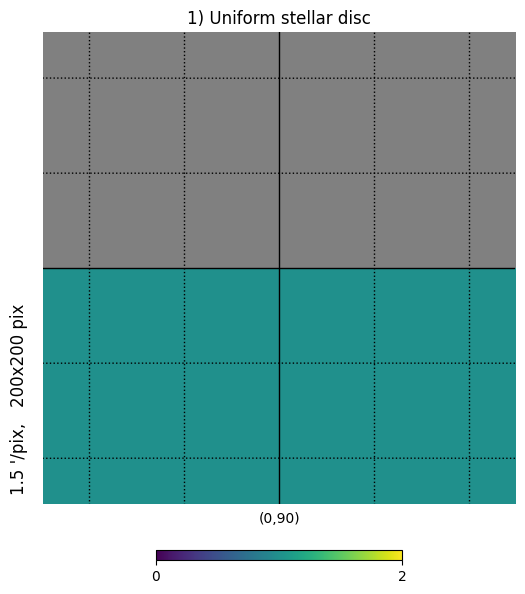

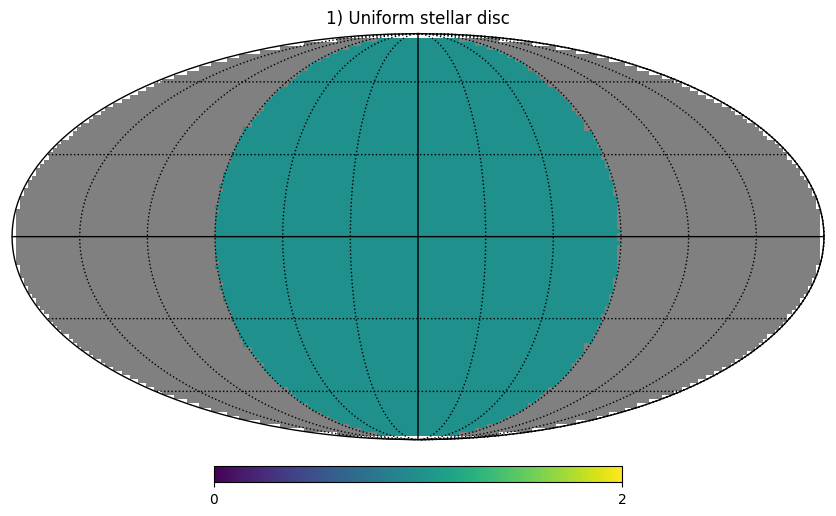

In [14]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# inline plotting
%matplotlib inline

# 1) MAKE A MAP OF A STAR
# -----------------------
NSIDE = 32
NPIX  = hp.nside2npix(NSIDE)
ipix  = np.arange(NPIX)

# get unit vectors for every pixel
x, y, z = hp.pix2vec(NSIDE, ipix)
theta, phi = hp.pix2ang(NSIDE, ipix)

# define the visible hemisphere (observer along +z)
visible = x > 0

# uniform‐brightness map
star_map = np.full(NPIX, hp.UNSEEN)
star_map[visible] = 1.0

# plot with a gnomonic projection centered on the sub‐observer point
hp.gnomview(
    star_map,
    rot=[0, 90],           # rotate so that +z is in center
    title="1) Uniform stellar disc",
    xsize=200,
)
hp.graticule()

hp.mollview(
    star_map,
    rot=[0, 0],           # rotate so that +z is in center
    title="1) Uniform stellar disc",
    xsize=200,
)
hp.graticule()


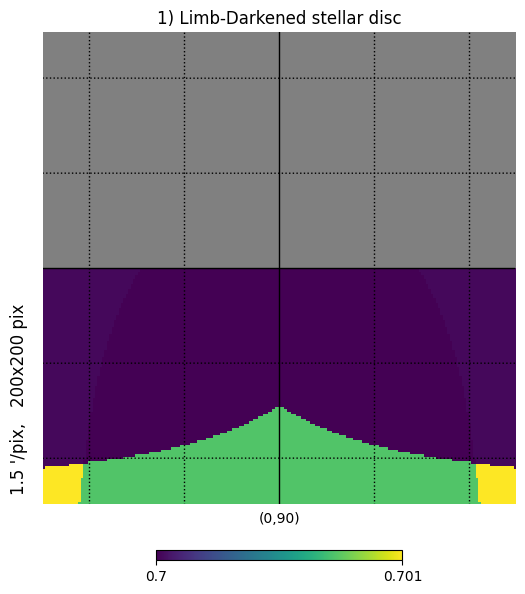

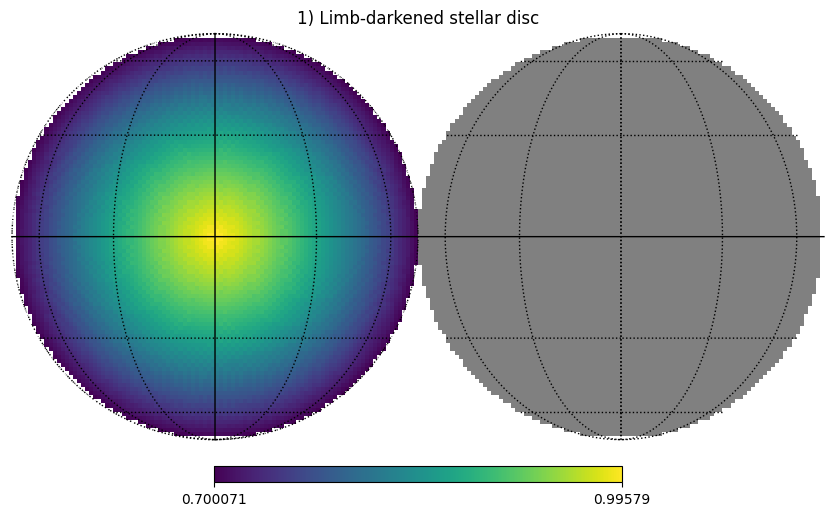

In [15]:
# Adding limb darkening

def quad_limb_dark(mu, u1, u2):
    """
    Compute the quadratic limb-darkening profile.

    Parameters
    ----------
    mu : array_like
        Cosine of the angle from the surface normal (μ = cos θ), between 0 and 1.
    u1, u2 : float
        Quadratic limb-darkening coefficients.

    Returns
    -------
    I_over_I0 : ndarray
        Normalized intensity I(μ)/I(1).
    """
    mu = np.asarray(mu)
    return 1.0 - u1*(1.0 - mu) - u2*(1.0 - mu)**2

# Example usage:
# mu = np.linspace(0, 1, 100)
# profile = quad_limb_dark(mu, u1=0.3, u2=0.2)


for pix in ipix[visible]:
    # mu = y^2 + z^2
    mu = 1-np.sqrt(y[pix]**2 + z[pix]**2)
    if mu > 1 or mu < 0:
        #make a warning
        print(f"Warning: mu value {mu} out of bounds for pixel {pix}.")

    mu = np.clip(mu, 0, 1)  # ensure mu is in [0, 1]

    # limb darkening coefficients
    u1, u2 = 0.2, 0.1

    # compute the intensity profile
    star_map[pix] = quad_limb_dark(mu, u1, u2)


# plot with a gnomonic projection centered on the sub‐observer point
hp.gnomview(
    star_map,
    rot=[0, 90],           # rotate so that +z is in center
    title="1) Limb-Darkened stellar disc",
    xsize=200,
)
hp.graticule()

hp.orthview(
    star_map,
    rot=[0, 0],           # rotate so that +z is in center
    title="1) Limb-darkened stellar disc",
    xsize=200,
)
hp.graticule()


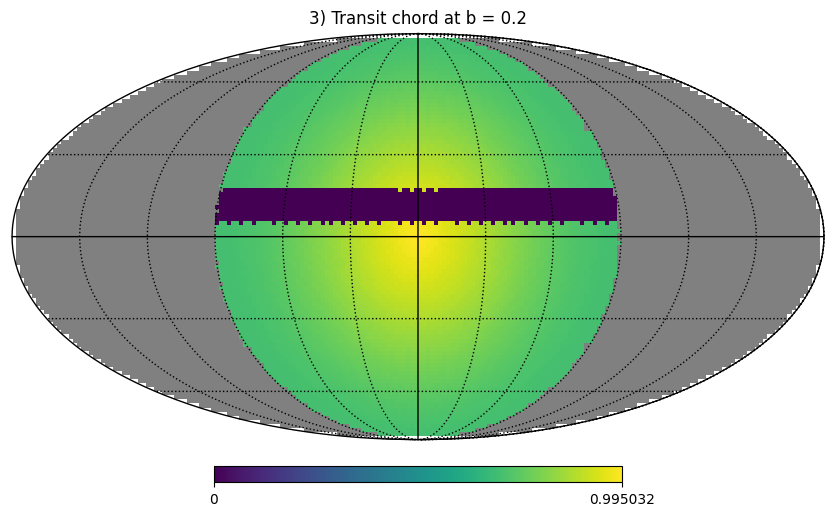

In [16]:
# 3) DEFINE A TRANSIT CHORD
# --------------------------
# For a planet with impact parameter b (in units of stellar radius), the chord
# runs at z = +b across the projected disc.  We’ll mask a narrow band around that.

b = 0.2             # impact parameter (0 = central, 1 = grazing)
chord_width = 0.1     # half‐width of the band

chord_map=star_map.copy()  # start with the star map

chord_mask = (np.abs(z - b) < chord_width) & visible

# visualize the chord alone
# chord_map = np.full(NPIX, hp.UNSEEN)
# chord_map[visible] = 1.0 - u_ld * (1.0 - z[visible])

chord_map[chord_mask] = 0

hp.mollview(
    chord_map,
    rot=[0, 0],
    title=f"3) Transit chord at b = {b}",
    xsize=200,
)
hp.graticule()


In [17]:
def closest_with_index(xs, target):
    # enumerate to keep track of original indices
    idx, val = min(enumerate(xs), key=lambda iv: abs(iv[1] - target))
    return idx, val

i, v = closest_with_index(y[visible], b)
print(i, v)   # → 2 3.7

close_indexes=np.isclose(y[visible], v,1e-1)  # → True

935 0.19985524047261954


In [18]:
close_indexes=ipix[visible][close_indexes]  # → [2, 3, 4]
print(close_indexes)  # → [2, 3, 4]

[  118   119   149   150   185   186   225   269   317   369   425   485
   549   617   689   765   845   929  1017  1109  1205  1305  1409  1517
  1629  1745  1865  1989  2117  2245  2373  2501  2629  2756  2885  3012
  3141  3268  3397  3524  3780  3908  4036  4164  4292  4420  4548  4676
  4804  4932  5060  5188  5316  5444  5572  5700  5828  5956  6084  6212
  6340  6468  6596  6724  6852  6980  7108  7236  7364  7492  7620  7748
  7876  8004  8132  8260  8388  8644  8773  8900  9029  9156  9285  9412
  9541  9669  9797  9925 10053 10181 10309 10433 10553 10669 10781 10889
 10993 11093 11189 11281 11369 11453 11533 11609 11681 11749 11813 11873
 11929 11981 12029 12073 12074 12113 12114 12150 12151]


In [19]:
y[50]

np.float64(-0.019916887071617456)

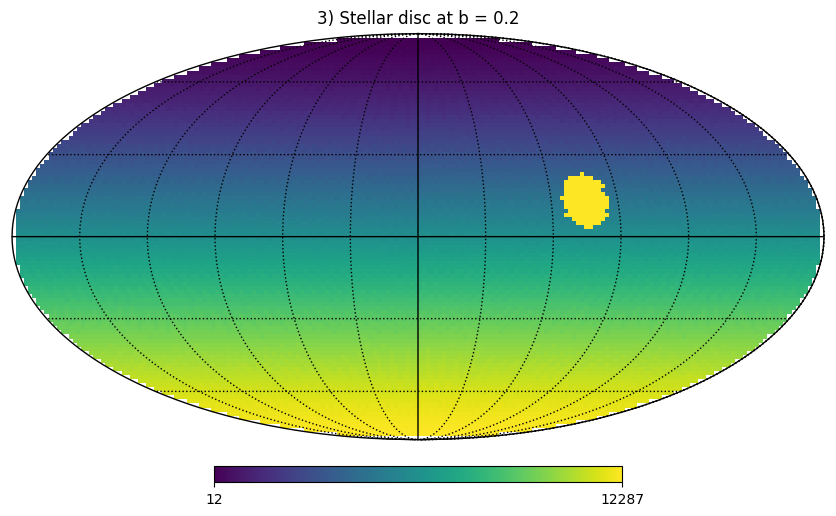

In [20]:
i= close_indexes[30]  # take the first one
vec=np.array([x[visible][i], y[visible][i], z[visible][i]])  # vector for the impact parameter
ipix_disc = hp.query_disc(nside=32, vec=vec, radius=np.radians(10))
m = np.arange(NPIX)
m[ipix_disc] = m.max()
hp.mollview(
    m,
    rot=[0, 0],
    title=f"3) Stellar disc at b = {b}",
    xsize=200,
)
hp.graticule()

In [21]:
# Manually calculating the transit chord
b=0.2
z_tr=np.ones(100) * b  # z values for the transit chord at impact parameter b

y_max_tr=np.sqrt(1-z_tr[0]**2)  # y_max for the transit chord

y_tr= np.linspace(-y_max_tr, y_max_tr, 100)  # y values for the transit chord
x_tr = np.sqrt(1 - y_tr**2 - z_tr**2)  # x values for the transit chord
vec_tr=np.array([x_tr, y_tr, z_tr]).T  # vectors for the transit chord

(100, 3)


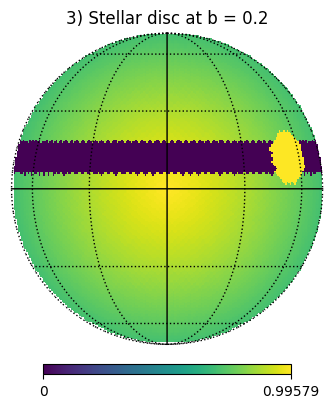

In [22]:
ii=10
vec_tr=np.array([x_tr, y_tr, z_tr]).T  # vectors for the transit chord
print(vec_tr.shape)  # → (100, 3)

ipix_disc = hp.query_disc(nside=32, vec=vec_tr[ii], radius=np.radians(10))

m=chord_map.copy()  # start with the star map
m[ipix_disc] = m.max()
hp.orthview(
    m,
    rot=[0, 0],
    title=f"3) Stellar disc at b = {b}",
    xsize=200,
    hold=True,  # keep the previous plot
    half_sky=True,  # show the whole sky
)
hp.graticule()

# # 3) Define a line of constant latitude (+30°) from lon = -180° to +180°
# lon = np.linspace(-180, 180, 200)
# lat = np.full_like(lon, 30.0)

# # Healpy expects (θ, φ) in radians, where
# #   θ = colatitude = 90° – latitude
# #   φ = longitude
# theta = np.radians(90.0 - lat)
# phi   = np.radians(lon)

# # 4) Overlay the line in black
# hp.projplot(theta, phi, '-k', linewidth=2)

# # 5) (Optional) Add a label using projtext
# hp.projtext(
#     np.radians(90.0 - 30.0),     # θ for label at lat=30°
#     np.radians(0.0),             # φ for label at lon=0°
#     "Lat +30°",
#     fontsize=14,
#     ha='center', va='bottom',
# )


how to add horizontal lines etc

In [23]:
# import numpy as np
# import healpy as hp

# # 1) Create a simple Healpix map (e.g. a smoothed random field)
# nside = 32
# np.random.seed(0)
# alm = hp.synalm(np.ones(3 * nside), lmax=3*nside-1)      # white-spectrum
# m = hp.alm2map(alm, nside=nside)

# # 2) Plot it in a Mollweide projection
# hp.mollview(
#     m,
#     title="Healpix Map with projplot Overlay",
#     unit="mK",
#     cmap="viridis"
# )
# hp.graticule()

# # 3) Define a line of constant latitude (+30°) from lon = -180° to +180°
# lon = np.linspace(-180, 180, 200)
# lat = np.full_like(lon, 30.0)

# # Healpy expects (θ, φ) in radians, where
# #   θ = colatitude = 90° – latitude
# #   φ = longitude
# theta = np.radians(90.0 - lat)
# phi   = np.radians(lon)

# # 4) Overlay the line in black
# hp.projplot(theta, phi, '-k', linewidth=2)

# # 5) (Optional) Add a label using projtext
# hp.projtext(
#     np.radians(90.0 - 30.0),     # θ for label at lat=30°
#     np.radians(0.0),             # φ for label at lon=0°
#     "Lat +30°",
#     fontsize=14,
#     ha='center', va='bottom',
# )


how to rotate maps

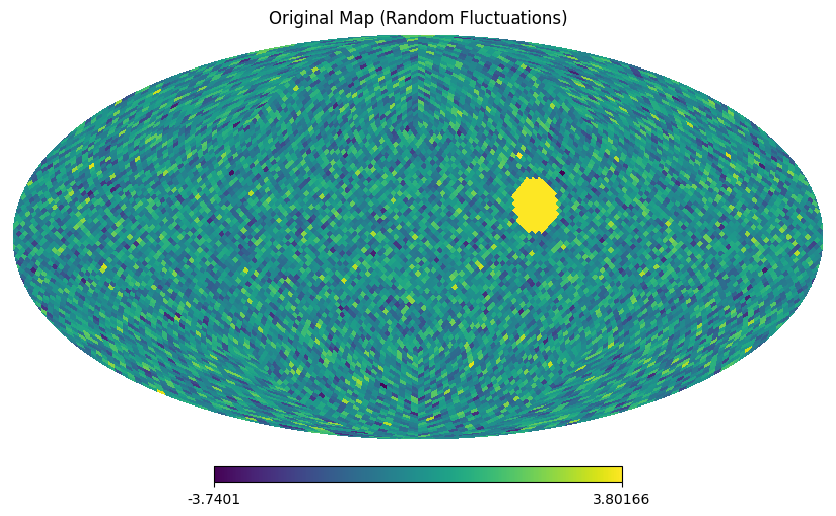

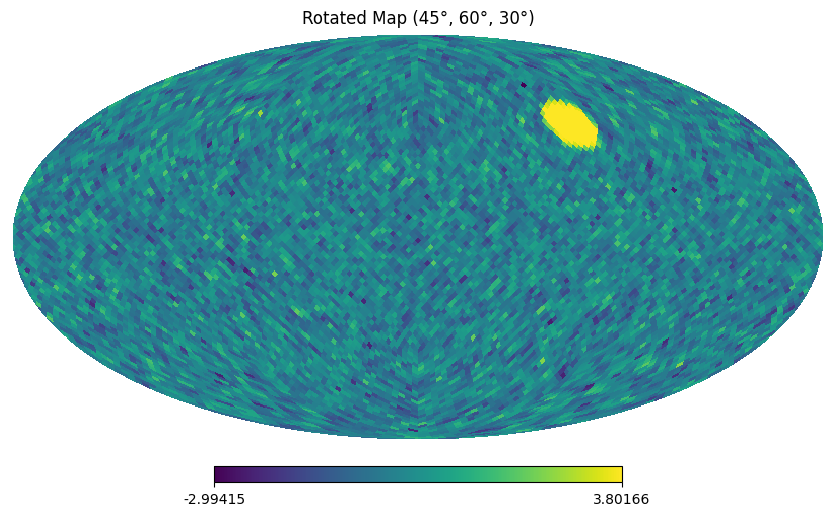

In [24]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Jupyter Notebook Example: Rotating a Healpy Map
# 1. Generate a sample map with random fluctuations
nside = 32
np.random.seed(0)
sample_map = np.random.randn(hp.nside2npix(nside))

ipix_disc = hp.query_disc(nside=32, vec=vec_tr[ii], radius=np.radians(10))
sample_map[ipix_disc] = sample_map.max()  # Highlight the disc


# 2. Define a Rotator with specified Euler angles (phi, theta, psi) in degrees
rotator = hp.Rotator(rot=[45, 60, 30], deg=True)

# 3. Rotate the map using pixel-based rotation
rotated_map = rotator.rotate_map_pixel(sample_map)

# 4. Plot the original map
hp.mollview(sample_map, title='Original Map (Random Fluctuations)')
plt.show()

# 5. Plot the rotated map
hp.mollview(rotated_map, title='Rotated Map (45°, 60°, 30°)')
plt.show()


Using projectors to get the transit path

In [25]:
from healpy.projector import MollweideProj

# Build a projection object with a rotation
proj = MollweideProj(rot=[0, 0, 0], xsize=800)

# Pick one sky direction
theta = np.radians(60)   # colatitude
phi   = np.radians(10)   # longitude

# Map to 2D Cartesian coords
x, y = proj.ang2xy(theta, phi)
print(f"2D coords = ({x:.1f}, {y:.1f})")

# And invert back:
th2, ph2 = proj.xy2ang(x, y)
print(f"Recovered (θ,φ) = ({np.degrees(th2):.1f}°, {np.degrees(ph2):.1f}°)")


2D coords = (-0.1, 0.4)
Recovered (θ,φ) = (60.0°, 10.0°)


In [ ]:
import numpy as np
from healpy.projector import OrthographicProj

# 1) Define your projection (center at lon0, lat0, and only the front hemisphere)
lon0, lat0 = 0.0, 0.0   # pick your center in degrees
proj = OrthographicProj(rot=[lon0, lat0, 0.0], half_sky=True)

# 2) Your “transit” in projection‐plane coords
#    x is fixed at 0.2, y runs from -1 to +1 (unit sphere)
b=0.2
x = np.ones(100)*b
y = np.linspace(-1.0, 1.0, 100)

theta_list = []
phi_list = []
for element in zip(x, y):
    theta, phi = proj.xy2ang(element[0], element[1])
    theta_list.append(theta)
    phi_list.append(phi)
theta = np.array(theta_list)
phi = np.array(phi_list)

# 4) (Optional) convert to more familiar latitude & longitude in degrees
lat = 90.0 - np.degrees(theta)   # latitude = 90° − colatitude
lon = np.degrees(phi)            # longitude

# 5) Inspect
for i in (0, 50, 99):
    print(f"xy = ({x[i]:0.2f}, {y[i]:0.2f}) → θ={theta[i]:0.2f} rad, φ={phi[i]:0.2f} rad → "
          f"lat={lat[i]:0.1f}°, lon={lon[i]:0.1f}°")


xy = (0.20, -1.00) → θ=nan rad, φ=nan rad → lat=nan°, lon=nan°
xy = (0.20, 0.01) → θ=1.56 rad, φ=-0.20 rad → lat=0.6°, lon=-11.5°
xy = (0.20, 1.00) → θ=nan rad, φ=nan rad → lat=nan°, lon=nan°


In [ ]:
i+=1

if not np.isnan(theta[i]) and not np.isnan(phi[i]):
    vec=hp.ang2vec(theta[i], lon[i])
    ipix_disc = hp.query_disc(nside=32, vec=vec, radius=np.radians(10))
    m = np.arange(hp.nside2npix(32))
    m[ipix_disc] = m.max()
    hp.orthview(
        m,
        rot=[0, 0],
        title=f"3) Stellar disc at b = {b}",
        xsize=200,
        hold=True,  # keep the previous plot
        half_sky=True,  # show the whole sky
    )
    hp.graticule()
else:
    print(f"Invalid theta or phi for index {i}: θ={theta[i]}, φ={phi[i]}")


IndexError: index 100 is out of bounds for axis 0 with size 100

Calculating the transit chord - version 2

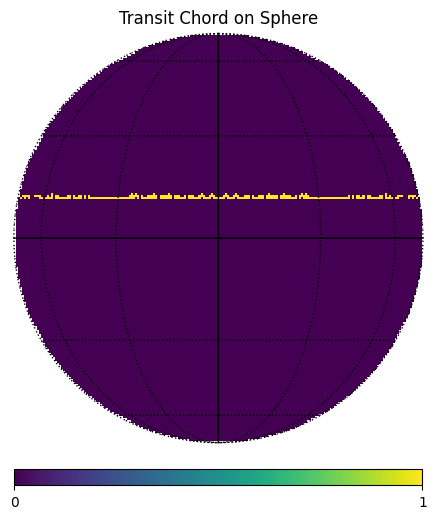

In [136]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

nside = 64
b     = 0.2
# maximum half-chord length on the stellar disk
y_max = np.sqrt(1 - b**2)

# 1) Build your chord in 3D (front hemisphere: z ≥ 0)
y_vals = np.linspace(-y_max, y_max, 200)
z_vals = np.full_like(y_vals, b)
x_vals = np.sqrt(1 - b**2 - y_vals**2)

# 2) Convert to spherical angles
vecs      = np.vstack((x_vals, y_vals, z_vals)).T
thetas, phis = hp.vec2ang(vecs)

# 3) Create a map and mark each chord pixel (optionally with a small disc)
transit_map = np.zeros(hp.nside2npix(nside))
for th, ph in zip(thetas, phis):
    ip = hp.ang2pix(nside, th, ph)
    transit_map[ip] = 1.0

# 4) Display
hp.orthview(transit_map, title="Transit Chord on Sphere",half_sky=True, xsize=200)
hp.graticule()
plt.show()


Making a lightcurve

In [9]:
vec_tr[0].shape

(3,)

Removing them


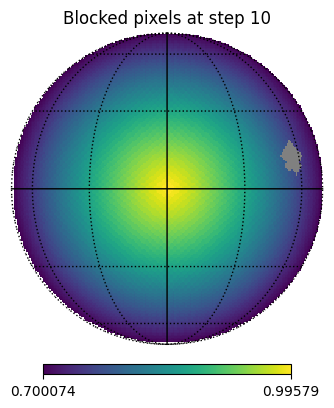

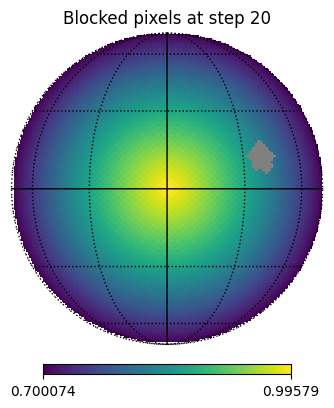

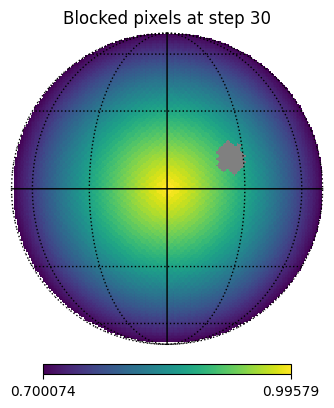

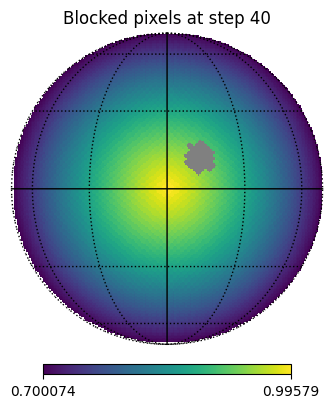

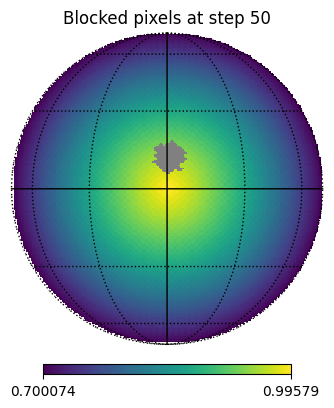

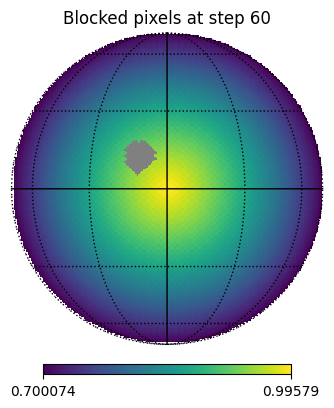

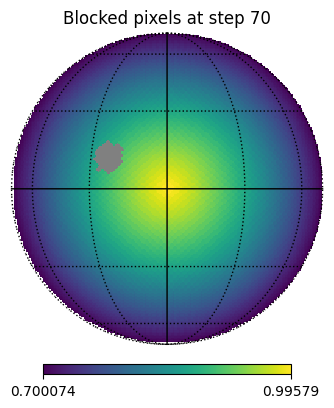

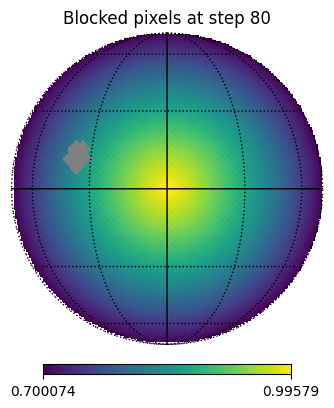

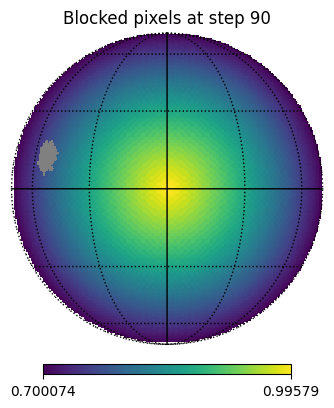

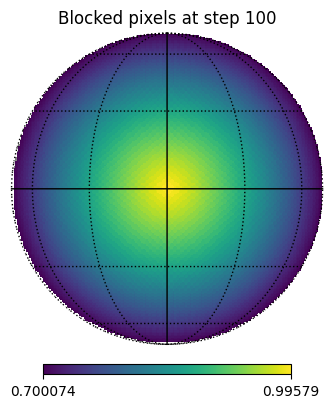

Removing them


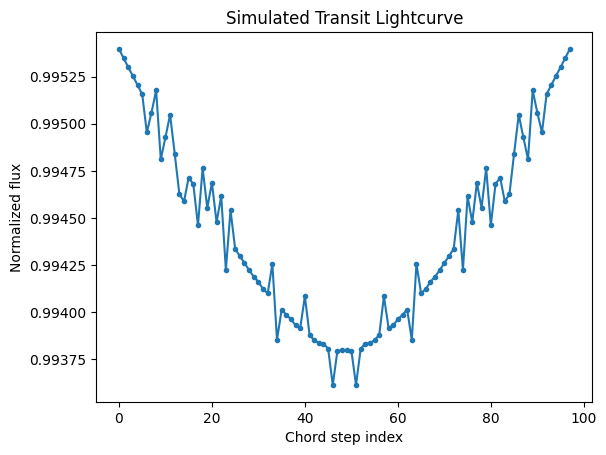

In [68]:
nside=32
rp=0.1
# total out-of-transit flux
F0 = star_map[visible].sum()

vec_tr=np.array([x_tr, y_tr, z_tr]).T  # vectors for the transit chord

# convert planet radius to angular (radians on unit sphere)
# small-angle approx: planet angular radius ≈ rp
ang_rp = rp

# 3) Loop to compute the lightcurve
flux = []
i=0
F_block_list=[]
for vec in vec_tr:
    i+=1
    # pixels blocked by planet
    ipix_block = hp.query_disc(nside, vec, radius=ang_rp)
    # ipix_block_in=ipix_bloc÷k[np.isin(ipix_block, ipix[visible])]  # only keep visible pixels

    blocked_map = star_map.copy()  # start with the star map
    blocked_map[ipix_block] = hp.UNSEEN  # mark blocked pixels as UNSEEN


    #plot every 10 steps
    if i % 10 == 0:
        hp.orthview(
            blocked_map,
            title=f"Blocked pixels at step {i}",
            half_sky=True,
            xsize=200,
            hold=True,  # keep the previous plot
        )
        hp.graticule()
        plt.show()

    vals=star_map[ipix_block]
    if (vals < 0).any():
        print(f"Warning: Negative flux in blocked pixels at step {i}.")
        print(F"Removing them")
        F_block= star_map[ipix_block][star_map[ipix_block] > 0].sum()
    else:
        # blocked flux = sum of those pixels
        F_block = star_map[ipix_block].sum()

    F_block_list.append(F_block)
    # residual flux
    flux.append((F0 - F_block) / F0)

flux = np.array(flux)

# 4) Plot the normalized lightcurve
plt.plot(flux[1:-1], '-o', ms=3)
plt.xlabel('Chord step index')
plt.ylabel('Normalized flux')
plt.title('Simulated Transit Lightcurve')
# plt.ylim(1 - (rp*rp*np.pi)/(4*np.pi) * 1.1, 1.01)  # rough y-scale
plt.show()
